# WISE Architecture – Trapped-Ion Animation Demo

This notebook compiles a Steane [[7,1,3]] QEC round on a WISE
trapped-ion architecture and animates the resulting ion-transport
schedule.

In [3]:
from __future__ import annotations
import os, sys
from collections import Counter
from types import SimpleNamespace

# ── Force complete module reload ────────────────────────────────────────
_stale = [k for k in list(sys.modules.keys()) if 'qectostim' in k]
for _k in _stale:
    del sys.modules[_k]
print(f'Cleared {len(_stale)} cached qectostim modules')

import numpy as np
import stim

# ── Trapped-ion pipeline ────────────────────────────────────────────────
from qectostim.experiments.hardware_simulation.trapped_ion import (
    WISEArchitecture,
    WISECompiler,
    TrappedIonExperiment,
    TrappedIonNoiseModel,
    display_architecture, animate_transport,
    QubitGate, MSGate, Measurement, GateSwap,
    Split, Merge, Move, JunctionCrossing,
    ParallelOperation,
)

from qectostim.codes.small.steane_713 import SteaneCode713

# ── Plotting ────────────────────────────────────────────────────────────
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display
matplotlib.rcParams['animation.embed_limit'] = 120  # MB cap for to_jshtml

# ── Helper: expand ReconfigurationPlanner ops into per-ion transports ──
def expand_reconfig_ops(ops):
    """Replace ReconfigurationPlanner objects with per-ion Move-like ops.

    The WISE SAT router produces batch ReconfigurationPlanner objects
    that move many ions atomically.  The animation code expects
    individual per-ion transport ops with source_zone / target_zone.
    This function expands them, inserting PASS_BOUNDARY sentinels
    so the animation groups each reconfiguration as one atomic step.
    """
    expanded = []
    for op in ops:
        movements = getattr(op, '_ion_movements', None)
        if type(op).__name__ == 'ReconfigurationPlanner' and movements:
            for ion_idx, src, tgt in movements:
                expanded.append(SimpleNamespace(
                    source_zone=src, target_zone=tgt,
                    qubits=(ion_idx,), ions=[], _ions=[],
                    metadata={'swap_type': 'RECONFIG'},
                ))
            # Boundary sentinel groups all moves from this reconfiguration
            expanded.append(SimpleNamespace(
                source_zone='__PASS_BOUNDARY__',
                target_zone='__PASS_BOUNDARY__',
                qubits=(-1,), ions=[], _ions=[],
            ))
        elif type(op).__name__ == 'ReconfigurationPlanner':
            pass  # No movement data — skip (initial placement or no-op)
        else:
            expanded.append(op)
    return expanded

print('✓ All imports OK')
print(f'  SteaneCode713: n={SteaneCode713().n}, k={SteaneCode713().k}')
assert hasattr(MSGate, 'qubitOperation'), 'MSGate missing qubitOperation!'
print('  MSGate.qubitOperation: ✓')

Cleared 174 cached qectostim modules
✓ All imports OK
  SteaneCode713: n=7, k=1
  MSGate.qubitOperation: ✓


## Compile

In [4]:
### Build WISE architecture and compile
wise_arch = WISEArchitecture(col_groups=3, rows=3, ions_per_segment=2)
code_wise = SteaneCode713()
comp_wise = WISECompiler(wise_arch)

print(f'Architecture : WISE 3x3x2  ({wise_arch.num_qubits} ions)')
print(f'Code         : Steane [[7,1,3]]  (n={code_wise.n}, k={code_wise.k})')

### Helper classes for 1Q gate animation
class _SingleQubitGateOp:
    def __init__(self, qubits, gate_type='R'):
        self.qubits = qubits
        self.ions = []
        self._ions = []
        self.metadata = {'gate_type': gate_type}
        self.name = gate_type
        self.gate_name = gate_type
_SingleQubitGateOp.__name__ = 'SingleQubitGate'
_SingleQubitGateOp.__qualname__ = 'SingleQubitGate'

class _MeasurementOp:
    def __init__(self, qubits, gate_type='M'):
        self.qubits = qubits
        self.ions = []
        self._ions = []
        self.metadata = {'gate_type': gate_type}
        self.name = gate_type
        self.gate_name = gate_type
_MeasurementOp.__name__ = 'Measurement'
_MeasurementOp.__qualname__ = 'Measurement'

try:
    exp_wise = TrappedIonExperiment(
        code=code_wise, architecture=wise_arch,
        compiler=comp_wise,
        hardware_noise=TrappedIonNoiseModel(), rounds=1,
    )
    ideal_wise = exp_wise.build_ideal_circuit()
    print(f'Ideal circuit: {ideal_wise.num_qubits} qubits, {len(ideal_wise)} instructions')

    n_data_wise = code_wise.n
    native_w = comp_wise.decompose_to_native(ideal_wise)
    mapped_w = comp_wise.map_qubits(native_w)
    routed_w = comp_wise.route(mapped_w)

    raw_wise_ops = routed_w.interleaved_operations()
    if not raw_wise_ops:
        raw_wise_ops = routed_w.routing_operations

    n_reconfig = sum(1 for o in raw_wise_ops if type(o).__name__ == 'ReconfigurationPlanner')
    n_ms_raw = sum(1 for o in raw_wise_ops if type(o).__name__ in ('MSGate', 'GateSwap'))
    print(f'Raw ops      : {len(raw_wise_ops)} total - {n_reconfig} reconfigs, {n_ms_raw} MS')

    wise_ops = expand_reconfig_ops(raw_wise_ops)

    ### Interleave 1Q gates from native circuit
    native_ops = native_w.operations if hasattr(native_w, 'operations') else []
    p2l_w = mapped_w.mapping.physical_to_logical
    _l2p = mapped_w.mapping.logical_to_physical
    _qi = wise_arch.qubit_ions
    _native_to_ion = {}
    for _nq, _gp in _l2p.items():
        if _gp < len(_qi):
            _native_to_ion[_nq] = _qi[_gp].idx
    print(f'Qubit map    : {len(_native_to_ion)} native qubits -> ion.idx')

    if native_ops:
        segments = []
        cur_1q = []
        for nop in native_ops:
            if len(nop.qubits) == 2:
                segments.append((cur_1q, nop))
                cur_1q = []
            else:
                cur_1q.append(nop)
        if cur_1q:
            segments.append((cur_1q, None))

        new_wise_ops = []
        ms_idx = 0

        if segments and segments[0][0]:
            batch = segments[0][0]
            qubit_groups = {}
            for op1q in batch:
                for q in op1q.qubits:
                    qubit_groups.setdefault(q, []).append(op1q)
            if qubit_groups:
                _ion_qubits = tuple(_native_to_ion.get(q, q) for q in qubit_groups.keys())
                _gtype = getattr(batch[0], 'name', 'R')
                new_wise_ops.append(_SingleQubitGateOp(_ion_qubits, _gtype))

        for i, op in enumerate(wise_ops):
            new_wise_ops.append(op)
            if type(op).__name__ in ('MSGate', 'GateSwap'):
                seg_idx = ms_idx + 1
                if seg_idx < len(segments):
                    post_1q, _ = segments[seg_idx]
                    if post_1q:
                        qubit_groups = {}
                        for op1q in post_1q:
                            for q in op1q.qubits:
                                qubit_groups.setdefault(q, []).append(op1q)
                        if qubit_groups:
                            gname = getattr(post_1q[0], 'name', 'R')
                            _ion_qubits = tuple(_native_to_ion.get(q, q) for q in qubit_groups.keys())
                            if gname in ('M', 'MX', 'MZ', 'MY'):
                                new_wise_ops.append(_MeasurementOp(_ion_qubits, gname))
                            else:
                                new_wise_ops.append(_SingleQubitGateOp(_ion_qubits, gname))
                ms_idx += 1

        wise_ops = new_wise_ops
        n_1q_injected = sum(1 for o in wise_ops if type(o).__name__ in ('SingleQubitGate', 'Measurement'))
        print(f'Interleaved  : {len(wise_ops)} ops ({n_1q_injected} 1Q/meas batches)')

    n_transport = sum(1 for o in wise_ops if getattr(o, 'source_zone', None) and getattr(o, 'source_zone', '') != '__PASS_BOUNDARY__')
    n_ms = sum(1 for o in wise_ops if type(o).__name__ in ('MSGate', 'GateSwap'))
    n_1q_final = sum(1 for o in wise_ops if type(o).__name__ == 'SingleQubitGate')
    n_meas_final = sum(1 for o in wise_ops if type(o).__name__ == 'Measurement')
    print(f'Final ops    : {len(wise_ops)} total - {n_transport} transports, {n_ms} MS, {n_1q_final} 1Q, {n_meas_final} meas')

    wise_roles = {}
    for i in range(wise_arch.num_qubits):
        lq = p2l_w.get(i)
        if lq is not None and lq < n_data_wise:
            wise_roles[i] = 'D'
        elif lq is not None:
            wise_roles[i] = 'M'
        else:
            wise_roles[i] = 'P'

    stim_wise = getattr(native_w, 'stim_source', None) or ideal_wise

    qi = wise_arch.qubit_ions
    wise_remap = {ion.idx: gp for gp, ion in enumerate(qi)}
    print(f'Ion remap    : {len(wise_remap)} entries')

    wise_p2l_display = {}
    for grid_pos in range(wise_arch.num_qubits):
        lq = p2l_w.get(grid_pos)
        if lq is not None:
            wise_p2l_display[grid_pos] = lq
    print(f'P2L display  : {wise_p2l_display}')
    print('Compilation succeeded')

except Exception as e:
    import traceback; traceback.print_exc()
    print(f'Compilation error: {type(e).__name__}: {e}')
    wise_ops = []
    wise_roles = {i: 'D' for i in range(7)}
    wise_roles.update({i: 'P' for i in range(7, wise_arch.num_qubits)})
    wise_remap = None
    wise_p2l_display = None
    stim_wise = ideal_wise if 'ideal_wise' in dir() else None

Architecture : WISE 3x3x2  (18 ions)
Code         : Steane [[7,1,3]]  (n=7, k=1)
Ideal circuit: 13 qubits, 54 instructions


SAT Routing: 100%|██████████| 12/12 [00:49<00:00,  4.10s/round, 0 ops left | reconfig 0.01s] 

Raw ops      : 182 total - 12 reconfigs, 24 MS
Qubit map    : 18 native qubits -> ion.idx
Interleaved  : 308 ops (146 1Q/meas batches)
Final ops    : 308 total - 102 transports, 24 MS, 136 1Q, 10 meas
Ion remap    : 18 entries
P2L display  : {0: 0, 1: 7, 2: 1, 3: 8, 4: 2, 5: 9, 6: 3, 7: 10, 8: 4, 9: 11, 10: 5, 11: 12, 12: 6, 13: 13, 14: 14, 15: 15, 16: 16, 17: 17}
Compilation succeeded


## Animate

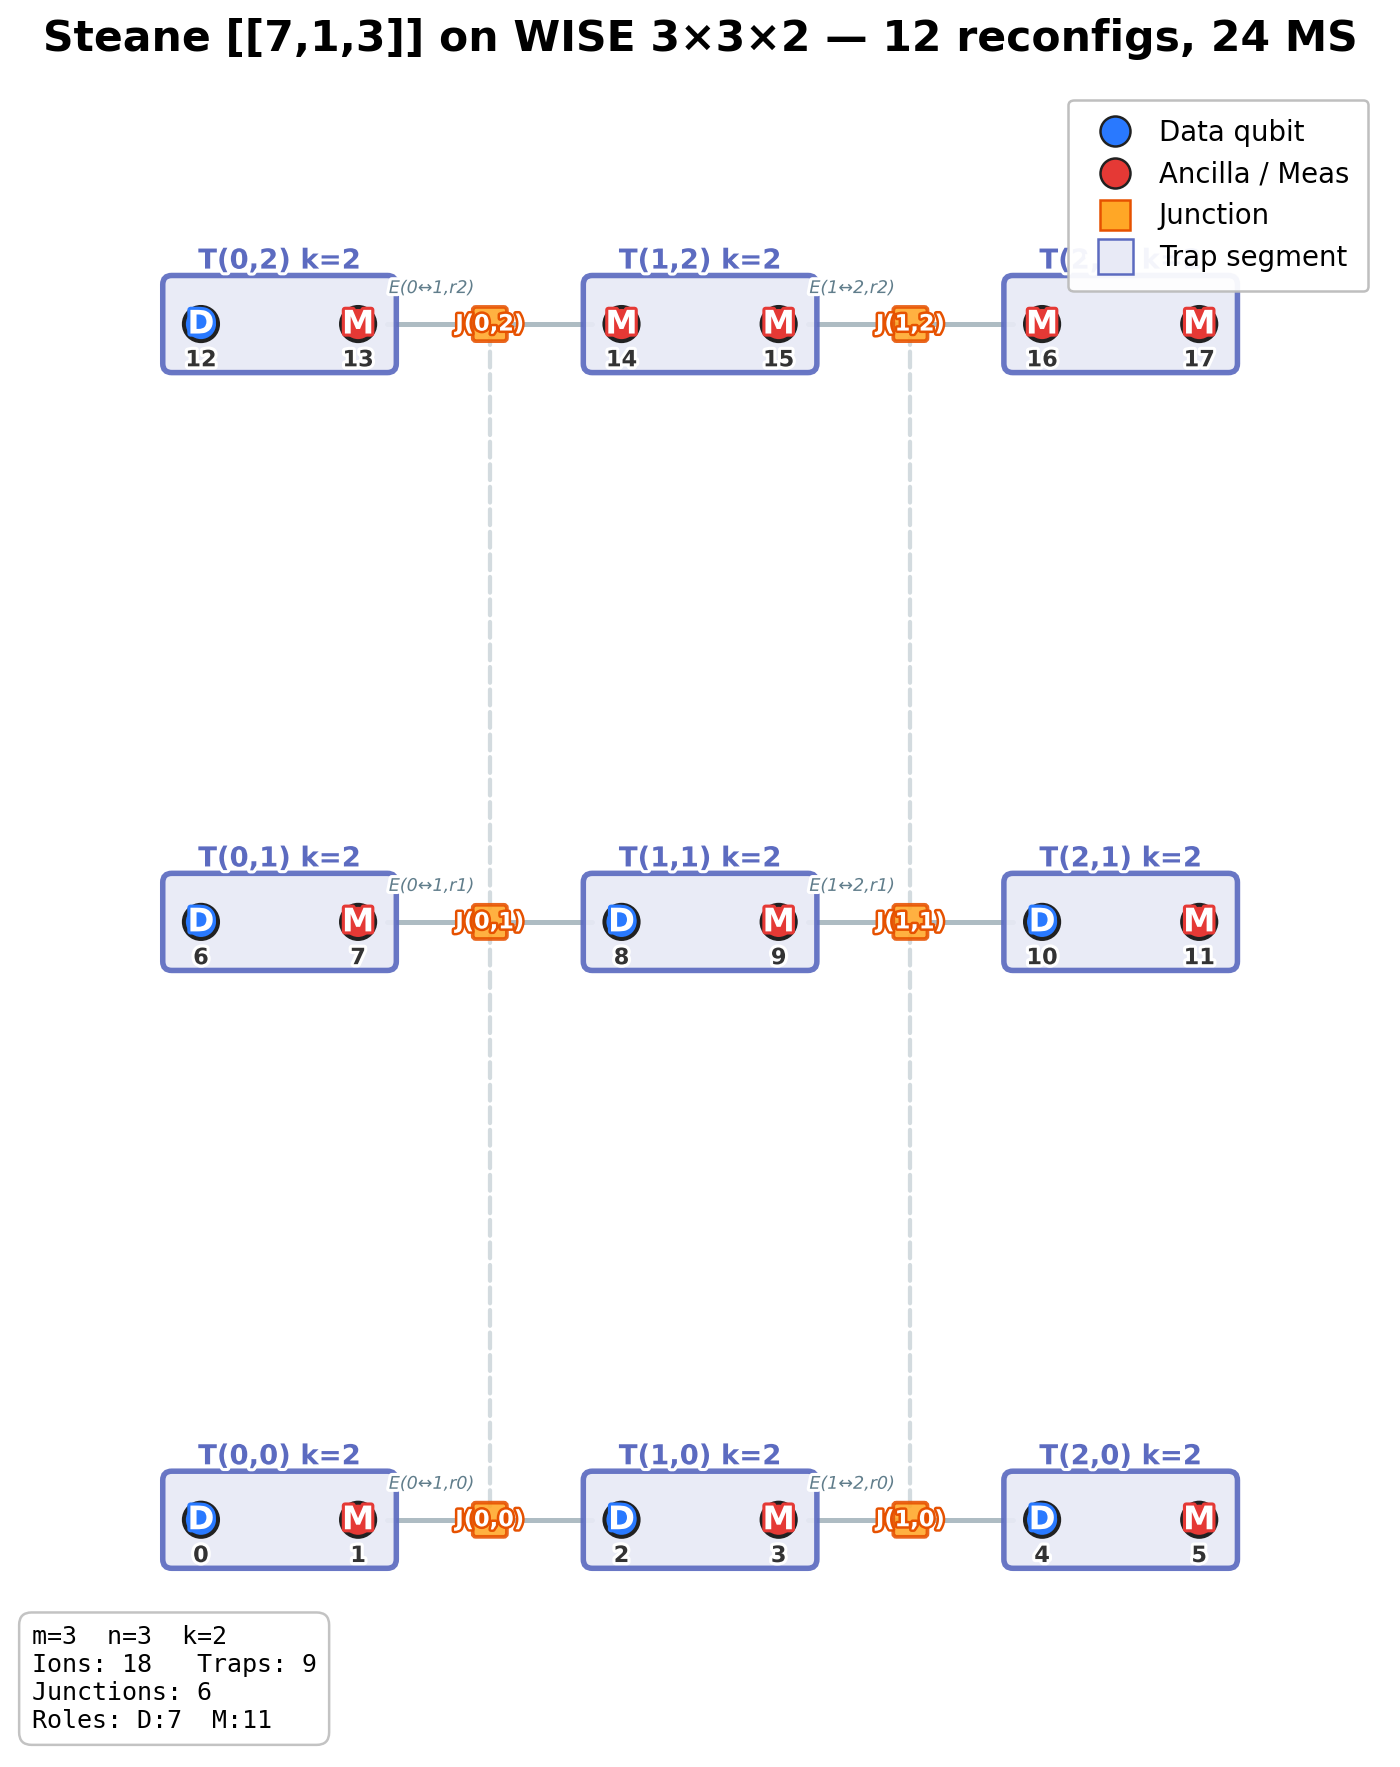

/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/trapped_ion/viz/visualization.py:1765: UserWarning: Trap (1, 1) capacity 2 exceeded by ion 4; routing may be incorrect
  _apply_swap_group(swap_list)
/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/trapped_ion/viz/visualization.py:1765: UserWarning: Trap (1, 0) capacity 2 exceeded by ion 13; routing may be incorrect
  _apply_swap_group(swap_list)
/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hardware_simulation/trapped_ion/viz/visualization.py:1765: UserWarning: Trap (1, 0) capacity 2 exceeded by ion 16; routing may be incorrect
  _apply_swap_group(swap_list)
/Users/scottjones_admin/Library/Mobile Documents/com~apple~CloudDocs/Mac files/Repos/QECToStim/src/qectostim/experiments/hard

In [5]:
# ── WISE: Static display + Transport animation ──────────────────────────
if wise_ops:
    # Static first frame
    fig_w, ax_w = display_architecture(
        wise_arch,
        title=f'Steane [[7,1,3]] on WISE 3×3×2 — {n_reconfig} reconfigs, {n_ms} MS',
        ion_roles=wise_roles, show_labels=True)
    plt.show()

    # Build animation (reduced frames to keep size manageable)
    try:
        anim_wise = animate_transport(
            wise_arch, wise_ops, interval=200, show_labels=True,
            ion_roles=wise_roles, interp_frames=4,
            gate_hold_frames=4, stim_circuit=stim_wise,
            ion_idx_remap=wise_remap,
            physical_to_logical=wise_p2l_display,
        )

        # Render interactive HTML5 player
        html_wise = anim_wise.to_jshtml(default_mode='loop')
        display(HTML(html_wise))
        print(f'✅ WISE animation: {len(html_wise)//1024} KB HTML')
        plt.close(anim_wise._fig)

    except Exception as e:
        import traceback; traceback.print_exc()
        print(f'⚠️  WISE animation error: {type(e).__name__}: {e}')
else:
    fig_w, ax_w = display_architecture(
        wise_arch,
        title='WISE 3×3×2 (no compiled ops — static only)',
        ion_roles=wise_roles, show_labels=True)
    plt.show()
    print('⚠️  No compiled ops — showing static architecture only')

In [ ]:
display(HTML(html_wise))